In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configurações ---
# Para melhor visualização dos plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7) # Define um tamanho padrão para os plots

# 1. Carrega o arquivo CSV com a codificação correta (utf-8)
df = pd.read_csv('News_Final.csv', encoding='utf-8')
print(f"Total de {len(df)} linhas e {len(df.columns)} colunas carregadas.")


Total de 93236 linhas e 11 colunas carregadas.


In [42]:

# 2. Limpeza e Preparação dos Dados
print("\n--- Limpando e Preparando os Dados ---")

# Tipagem de dados - Colunas Datetime
df['PublishDate'] = pd.to_datetime(df['PublishDate'], errors='coerce')

# Tratar strings vazias em 'Topic' e 'Source'
df['Headline'].replace('', 'Unknown', inplace=True)
df['Source'].replace('', 'Unknown', inplace=True)

# Tipagem de dados - Colunas Numéricas
social_cols = ['Facebook', 'GooglePlus', 'LinkedIn']
for col in social_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = np.where(df[col] == -1, np.nan, df[col])
df['SentimentTitle'] = pd.to_numeric(df['SentimentTitle'], errors='coerce')
df['SentimentHeadline'] = pd.to_numeric(df['SentimentHeadline'], errors='coerce')





--- Limpando e Preparando os Dados ---


In [43]:

# 3. Informações Básicas
print("\n--- Informações Básicas do DataFrame ---")
print("Primeiras 5 linhas:")
print(df.head())

print("\nInformações Gerais (Tipos de Dados, Valores Não-Nulos):")
df.info()

print("\nEstatísticas Descritivas (Colunas Numéricas):")
# Incluindo percentis para melhor entendimento da distribuição
print(df.describe(percentiles=[.01, .25, .5, .75, .99]))

print("\nContagem de Valores Ausentes por Coluna (após limpeza inicial):")
print(df.isnull().sum())



--- Informações Básicas do DataFrame ---
Primeiras 5 linhas:
    IDLink                                              Title  \
0  27788.0                          Finland GDP Expands In Q4   
1  27789.0  Tourism, govt spending buoys Thai economy in J...   
2  27790.0  Intellitec Solutions to Host 13th Annual Sprin...   
3  80690.0                                Monday, 29 Feb 2016   
4  80762.0  Obama, stars pay a musical tribute to Ray Charles   

                                            Headline  \
0  Finland's economy expanded marginally in the t...   
1  Tourism and public spending continued to boost...   
2  Over 100 attendees expected to see latest vers...   
3  RAMALLAH, February 25, 2016 (WAFA) - Palestine...   
4  First lady Michelle Obama speaks in the State ...   

                                     Source      Topic         PublishDate  \
0                                  RTT News    economy 2015-03-01 00:06:00   
1  The Nation - Thailand&#39;s English news    economy


--- Análise de Tópicos ---
Contagem de Artigos por Tópico:
Topic
economy      33926
obama        28609
microsoft    21858
palestine     8843
Name: count, dtype: int64


C:\Users\fabricio_folmer\AppData\Local\Temp\ipykernel_10236\3424501468.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis', order=topic_counts.index)


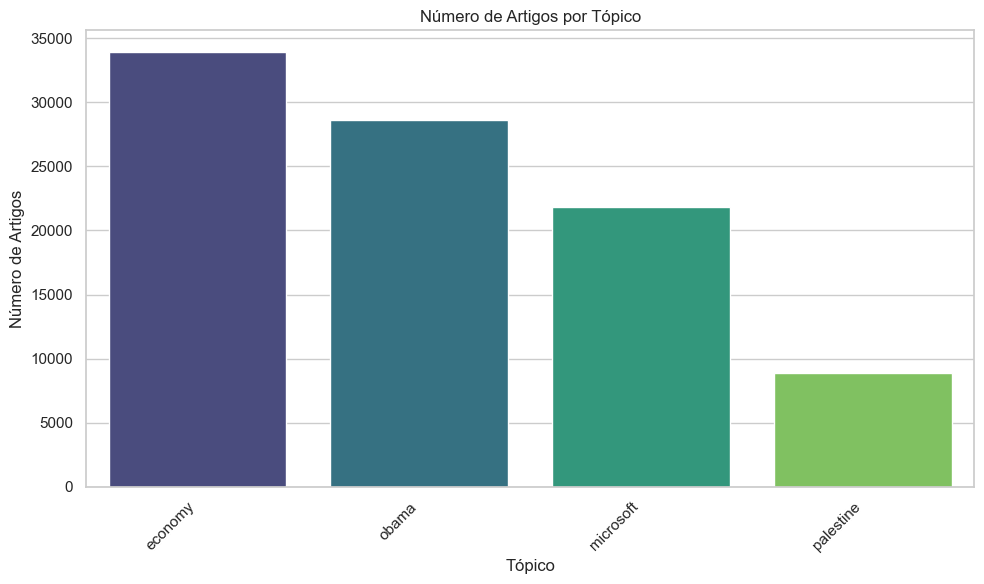

In [44]:
# 4. Análise de Tópicos
print("\n--- Análise de Tópicos ---")
topic_counts = df['Topic'].value_counts()
print("Contagem de Artigos por Tópico:")
print(topic_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='viridis', order=topic_counts.index)
plt.title('Número de Artigos por Tópico')
plt.xlabel('Tópico')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



--- Análise de Fontes ---
Top 20 Fontes por Contagem de Artigos:
Source
Bloomberg                     1730
Reuters                       1321
ABC News                      1098
New York Times                 992
The Guardian                   933
Business Insider               884
Economic Times                 787
Forbes                         781
Washington Post                774
CNN                            742
Wall Street Journal            730
WinBeta                        707
CNBC                           682
Huffington Post                676
Breitbart News                 605
Reuters via Yahoo! Finance     551
The Hill                       548
Financial Times                544
USA TODAY                      529
ZDNet                          526
Name: count, dtype: int64


C:\Users\fabricio_folmer\AppData\Local\Temp\ipykernel_10236\1957219171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.head(top_n_sources).index, y=source_counts.head(top_n_sources).values, palette='magma', order=source_counts.head(top_n_sources).index)


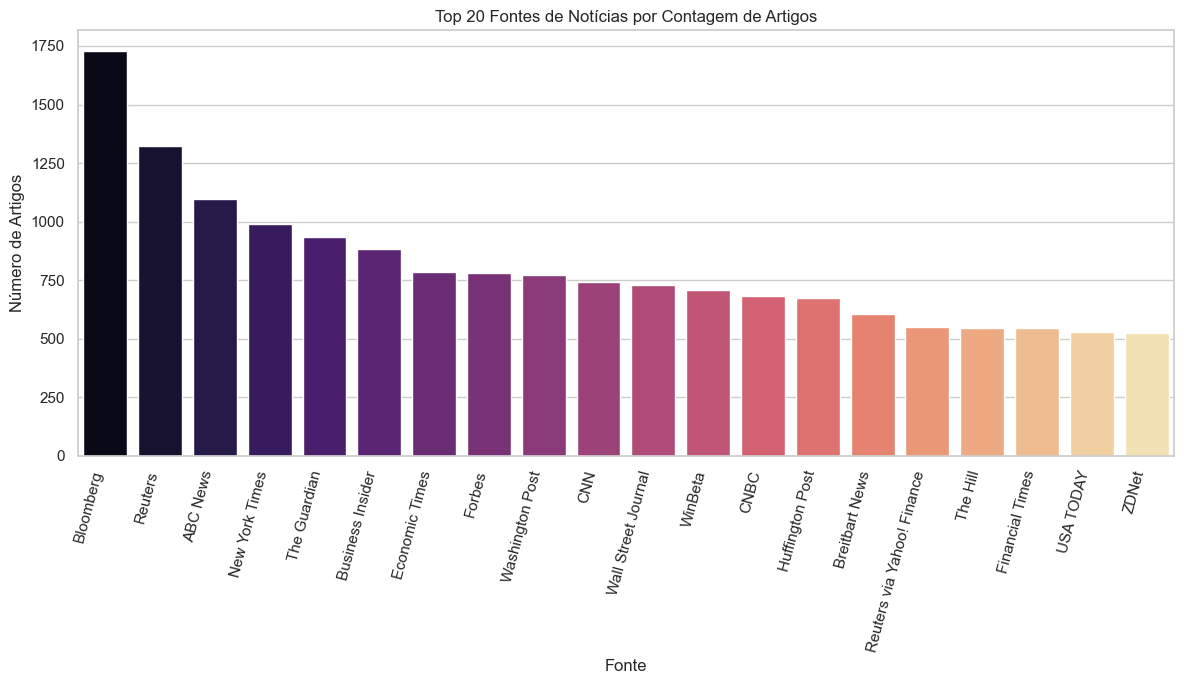

In [45]:

# 5. Análise de Fontes
print("\n--- Análise de Fontes ---")
source_counts = df['Source'].value_counts()
top_n_sources = 20
print(f"Top {top_n_sources} Fontes por Contagem de Artigos:")
print(source_counts.head(top_n_sources))

plt.figure(figsize=(12, 7))
sns.barplot(x=source_counts.head(top_n_sources).index, y=source_counts.head(top_n_sources).values, palette='magma', order=source_counts.head(top_n_sources).index)
plt.title(f'Top {top_n_sources} Fontes de Notícias por Contagem de Artigos')
plt.xlabel('Fonte')
plt.ylabel('Número de Artigos')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()


In [49]:
# Análise Temporal
print("\n--- Análise Temporal ---")
# Define 'PublishDate' como índice para facilitar a reamostragem
df_time = df.set_index('PublishDate')

# Número de artigos por mês
plt.figure(figsize=(12, 6))
df_time.resample('ME').size().plot(kind='line', marker='o') 
plt.title('Número de Artigos Publicados por Mês')
plt.xlabel('Mês')
plt.ylabel('Número de Artigos')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sentimento médio da manchete ao longo do tempo (mensal)
plt.figure(figsize=(14, 7))
df_time.resample('ME')['SentimentHeadline'].mean().plot(kind='line') # ME = Month End
plt.title('Sentimento Médio da Manchete ao Longo do Tempo (Mensal)')
plt.xlabel('Mês')
plt.ylabel('Sentimento Médio da Manchete')
plt.axhline(0, color='grey', linestyle='--') # Linha neutra
plt.grid(True)
plt.tight_layout()
plt.show()


--- Análise Temporal ---


ValueError: Invalid frequency: ME

<Figure size 1200x600 with 0 Axes>

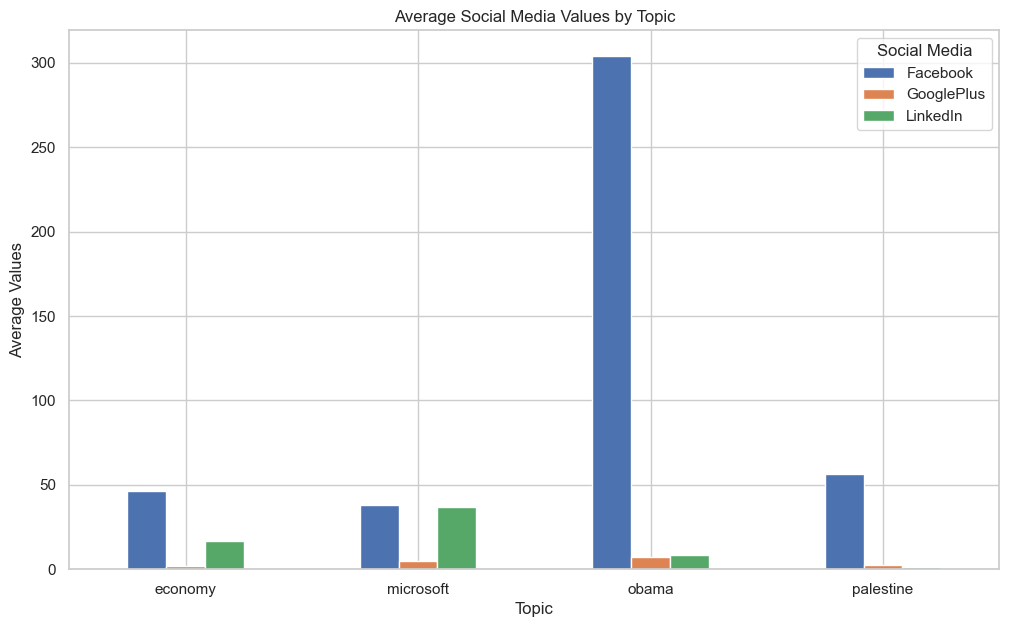

In [47]:
# 6. Análise de Sentimento médio por rede social ('Facebook', 'GooglePlus', 'LinkedIn'),
# Calcula o sentimento médio por valores de engajamento social para cada rede social

# Calcula a média de engagamento por Rede Social, por tópico
average_values = df.groupby('Topic')[['Facebook', 'GooglePlus', 'LinkedIn']].mean()

# Exibe os resultados
average_values.plot(kind='bar')
plt.title('Average Social Media Values by Topic')
plt.xlabel('Topic')
plt.ylabel('Average Values')
plt.xticks(rotation=0)
plt.legend(title='Social Media')
plt.show()



C:\Users\fabricio_folmer\AppData\Local\Temp\ipykernel_10236\1972499980.py:3: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['BestSocialMedia'] = df[social_cols].idxmax(axis=1)
C:\Users\fabricio_folmer\AppData\Local\Temp\ipykernel_10236\1972499980.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_social_media_counts.index, y=best_social_media_counts.values, palette='pastel')


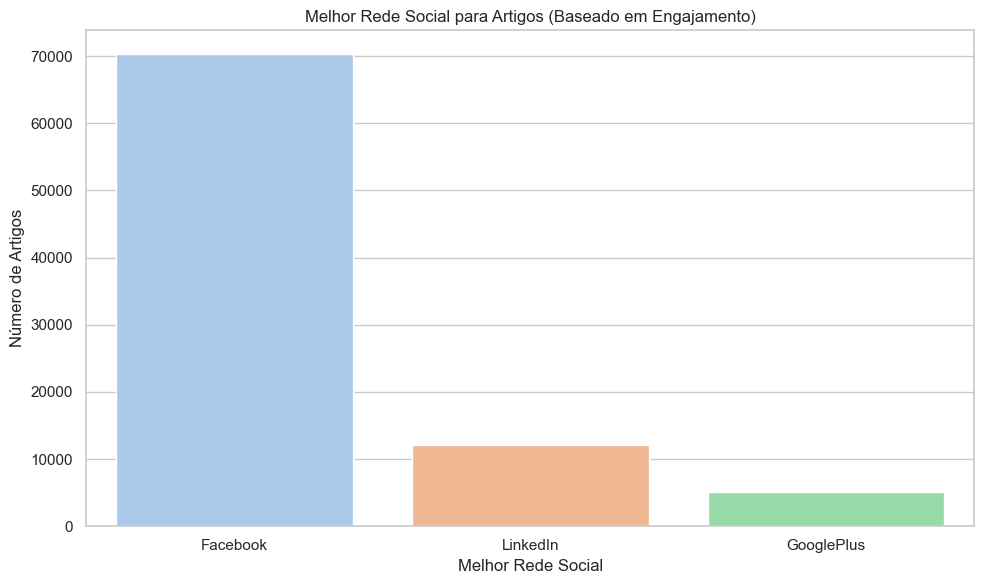

In [48]:
# Cria uma nova coluna 'BestSocialMedia' que identifica a melhor rede social para cada artigo
# com base no maior valor de engajamento
df['BestSocialMedia'] = df[social_cols].idxmax(axis=1)

# Filtra os artigos que têm pelo menos uma rede social com valor válido
df_filtered = df.dropna(subset=social_cols, how='all')

# Contagem de artigos por melhor rede social
best_social_media_counts = df_filtered['BestSocialMedia'].value_counts()

# Exibe os resultados
plt.figure(figsize=(10, 6))
sns.barplot(x=best_social_media_counts.index, y=best_social_media_counts.values, palette='pastel')
plt.title('Melhor Rede Social para Artigos (Baseado em Engajamento)')
plt.xlabel('Melhor Rede Social')
plt.ylabel('Número de Artigos')
plt.tight_layout()
plt.show()